In [18]:
import pandas as pd
import os
from sqlalchemy import create_engine, text
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
DB_HOST = os.getenv("DB_HOST", "db")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "weather_db")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "postgres")

DATABASE_URL = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [3]:
DATABASE_URL

'postgresql+psycopg2://postgres:postgres@db:5432/weather_db'

In [4]:
engine = create_engine(DATABASE_URL)

In [5]:
with engine.connect() as conn:
    loc_df = pd.read_sql("select * from location", conn)
    weather_df = pd.read_sql("select * from weather_observation", conn)

In [6]:
loc_df

,id,city,state,country,latitude,longitude,created_at
0,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00
1,6369fbd3-9504-48f4-8a86-2216115631ff,Bothell,WA,USA,47.7623,-122.2054,2026-05-15 17:26:10.280675+00:00
2,156a2005-8867-49e2-ba4e-8176d8b992e8,Portland,OR,USA,45.5152,-122.6784,2026-05-15 17:26:10.280675+00:00


In [7]:
weather_df.head()

,id,location_id,observed_at,temperature,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at
0,8aa64b16-011d-4908-9ccb-803cfff6f63e,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 00:00:00+00:00,4.2,2.4,90.0,None,1.1,None,3,None,2026-05-15 17:26:11.758867+00:00
1,0569bc54-8f16-4063-bcb1-f2f30ececc27,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 01:00:00+00:00,2.6,0.1,88.0,None,3.9,None,45,None,2026-05-15 17:26:11.758867+00:00
2,2f71ae9d-c559-43c5-911c-0c19874f6a68,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 02:00:00+00:00,2.8,0.7,90.0,None,1.9,None,45,None,2026-05-15 17:26:11.758867+00:00
3,4315edc4-a8ce-4141-a05e-a5237f3879a5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 03:00:00+00:00,3.1,1.2,94.0,None,1.5,None,45,None,2026-05-15 17:26:11.758867+00:00
4,6915ad56-c46c-4ab1-b322-36b1d13430d7,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 04:00:00+00:00,2.5,0.4,91.0,None,1.8,None,45,None,2026-05-15 17:26:11.758867+00:00


In [8]:
weather_df.dtypes

id                                  object
location_id                         object
observed_at            datetime64[us, UTC]
temperature                        float64
feels_like                         float64
humidity                           float64
pressure                            object
wind_speed                         float64
weather_description                 object
weather_code                         int64
raw_json                            object
created_at             datetime64[us, UTC]
dtype: object

In [9]:
combined = loc_df.merge(weather_df, left_on='id', right_on='location_id', suffixes=['_loc', '_wea'])

In [10]:
combined.head()

,id_loc,city,state,country,latitude,longitude,created_at_loc,id_wea,location_id,observed_at,temperature,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at_wea
0,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,8aa64b16-011d-4908-9ccb-803cfff6f63e,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 00:00:00+00:00,4.2,2.4,90.0,None,1.1,None,3,None,2026-05-15 17:26:11.758867+00:00
1,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,0569bc54-8f16-4063-bcb1-f2f30ececc27,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 01:00:00+00:00,2.6,0.1,88.0,None,3.9,None,45,None,2026-05-15 17:26:11.758867+00:00
2,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,2f71ae9d-c559-43c5-911c-0c19874f6a68,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 02:00:00+00:00,2.8,0.7,90.0,None,1.9,None,45,None,2026-05-15 17:26:11.758867+00:00
3,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,4315edc4-a8ce-4141-a05e-a5237f3879a5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 03:00:00+00:00,3.1,1.2,94.0,None,1.5,None,45,None,2026-05-15 17:26:11.758867+00:00
4,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,6915ad56-c46c-4ab1-b322-36b1d13430d7,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-01 04:00:00+00:00,2.5,0.4,91.0,None,1.8,None,45,None,2026-05-15 17:26:11.758867+00:00


In [11]:
combined.groupby('city')['temperature'].mean()

city
Bothell     7.456840
Portland    8.185174
Seattle     7.226146
Name: temperature, dtype: float64

In [12]:
combined.groupby('city')['feels_like'].mean()

city
Bothell     5.297153
Portland    5.817708
Seattle     4.759479
Name: feels_like, dtype: float64

Text(0, 0.5, 'Feels Like (C)')

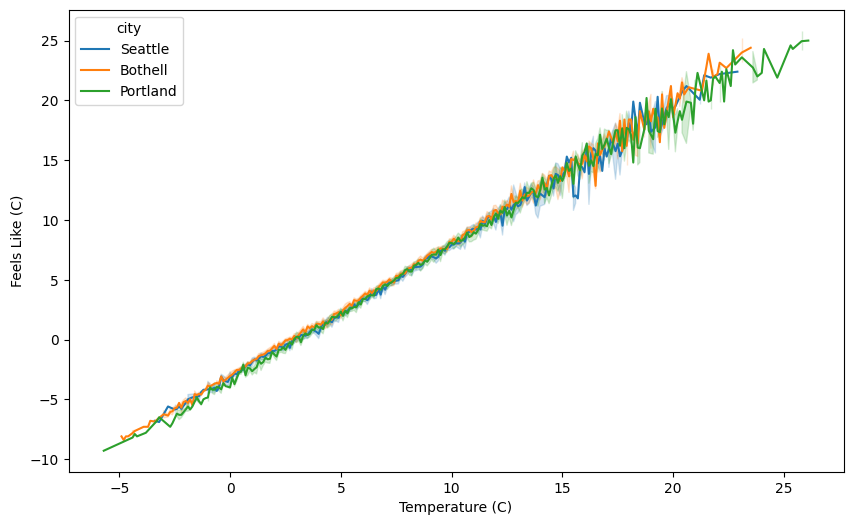

In [19]:
sns.lineplot(data=combined, x='temperature', y='feels_like', hue='city')
plt.xlabel("Temperature (C)")
plt.ylabel("Feels Like (C)")

<Axes: xlabel='observed_at', ylabel='temperature'>

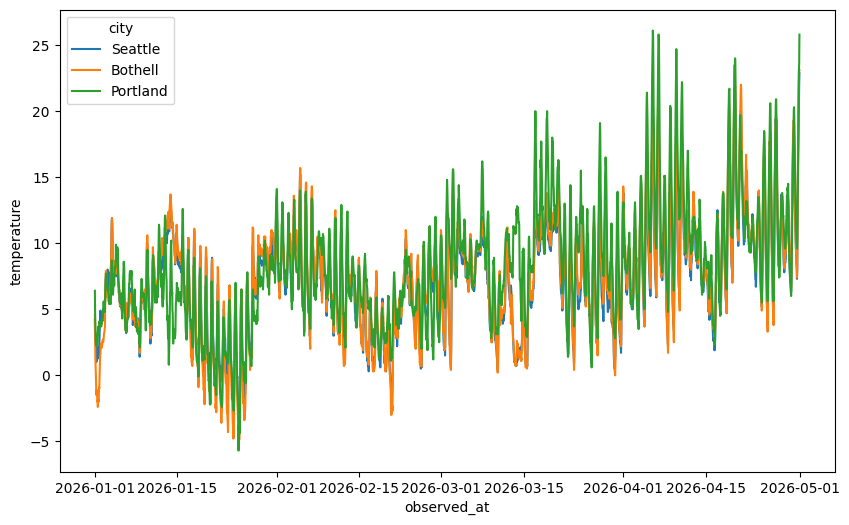

In [20]:
sns.lineplot(data=combined, x='observed_at', y='temperature', hue='city')

In [15]:
combined.shape

(8640, 19)

In [16]:
combined['observed_at'].max()

Timestamp('2026-04-30 23:00:00+0000', tz='UTC')

In [17]:
combined['observed_at'].min()

Timestamp('2026-01-01 00:00:00+0000', tz='UTC')

In [23]:
combined['month'] = combined['observed_at'].dt.month_name()

In [24]:
combined.groupby(['city', 'month'])['temperature'].mean()

city      month   
Bothell   April       10.812361
          February     6.413393
          January      5.272581
          March        7.336290
Portland  April       11.810278
          February     6.628423
          January      4.825941
          March        9.442339
Seattle   April       10.297361
          February     6.108929
          January      5.559274
          March        6.929973
Name: temperature, dtype: float64

In [26]:
pivot = pd.pivot_table(data=combined, index='city', columns='month', values='temperature', aggfunc='mean')


In [27]:
month_order = ["January", "February", "March", "April"]
pivot = pivot.reindex(columns=month_order)

In [28]:
pivot

month,January,February,March,April
city,,,,
Bothell,5.272581,6.413393,7.336290,10.812361
Portland,4.825941,6.628423,9.442339,11.810278
Seattle,5.559274,6.108929,6.929973,10.297361


<Axes: xlabel='month'>

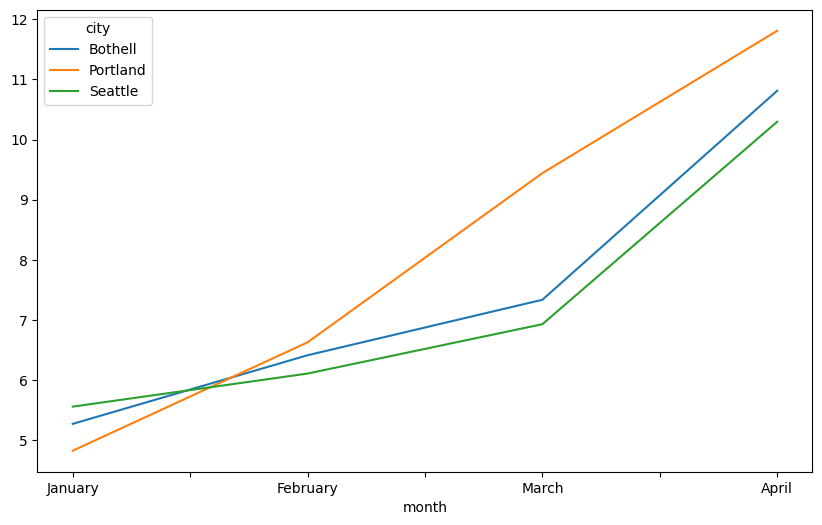

In [32]:
pivot.T.plot()

In [35]:
combined['observed_at'].value_counts

<bound method IndexOpsMixin.value_counts of 0      2026-01-01 00:00:00+00:00
1      2026-01-01 01:00:00+00:00
2      2026-01-01 02:00:00+00:00
3      2026-01-01 03:00:00+00:00
4      2026-01-01 04:00:00+00:00
                  ...           
8635   2026-04-30 19:00:00+00:00
8636   2026-04-30 20:00:00+00:00
8637   2026-04-30 21:00:00+00:00
8638   2026-04-30 22:00:00+00:00
8639   2026-04-30 23:00:00+00:00
Name: observed_at, Length: 8640, dtype: datetime64[us, UTC]>